# SAE estimation for target variable in Cambodia

This Jupyter Notebook implements a Small Area Estimation (SAE) approach using an OLS model to predict the target variable at the village level. The workflow follows the methodology proposed by Van der Weide et al. (2022), and includes the following steps:

1. Data preparation and selection (after selection of relevant covariates from Lasso),

2. Spatial autocorrelation diagnostics (e.g. Moran’s I),
3. Weight criteria specification for spatial weight matrix (W)
3. Predictions from OLS trained model
4. Estimation of the SEM using two spatial weight matrix criteria
5. Selection of SEM model and prediction of the target indicator using this trained model
6. Monte Carlo simulations to compute confidence intervals for predicted values.


In [1]:
#!pip install pysal libpysal esda

In [2]:
#Imports  
import pandas as pd
import geopandas as gpd
import os
import pickle
import numpy as np
from sklearn.linear_model import LinearRegression
from pysal.model import spreg
from libpysal.weights import KNN, lag_spatial, DistanceBand
import matplotlib.pyplot as plt
from esda.moran import Moran
import seaborn as sns
from scipy.spatial import distance_matrix
from spreg import GM_Error
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error
from esda.moran import Moran
from scipy.sparse import csr_matrix, identity
from scipy.sparse.linalg import inv, spsolve, LinearOperator, cg
from numpy.linalg import inv as dense_inv

### Parameters

In [3]:
data_folder_SAE=r"C:\Users\laura\Vestigium Métodos Mixtos Aplicados SAS\Daniel Wiesner - DISES\SAE\SAE - Nutrition\data"
nis_year=2006
dhs_year=2005

### Loading data

In [4]:
nis06=gpd.read_file(os.path.join(data_folder_SAE,fr"underlying\sae-nis-complete-{nis_year}.shp"))
nis06.head()
print(nis06.crs)

EPSG:32648


In [5]:
dhs05=gpd.read_file(os.path.join(data_folder_SAE,fr"underlying\sae-dhs-underlying-{dhs_year}.shp"))
dhs05.head()
print(dhs05.crs)

EPSG:32648


In [6]:

# Load the GeoDataFrame from a .pkl file after applying feature selection of relevant covariates with Lasso in "1. Covariate Selection-SAE.ipynb" file

# .pkl path
with open(r"C:\Users\laura\Vestigium Métodos Mixtos Aplicados SAS\Daniel Wiesner - DISES\SAE\SAE - Nutrition\temp_files\selected_features_full.pkl", "rb") as f:
    gdf = pickle.load(f)

# Check the type of file
print(type(gdf))     

<class 'geopandas.geodataframe.GeoDataFrame'>


In [7]:
# Check the number of unique geometries, to prove there aren't duplicates.
print(gdf["geometry"].nunique())
print(gdf["geometry"].count())

12076
12076


In [8]:
gdf.head()

,rate_nutr,geometry,grid_id,523-C_MORT,534-LQ_ROO,517-UNIMPR,pa_binary,slope,northness,wealth_200,y2004_STme,y2005_STme,pobcount20,%crops,%builtarea,%baregnd,NPP_10_23,EVI_10_23,n_ducks
0,0.214286,POINT (292145.977 1210105.958),id7358,4.615121,0.170893,1.734902,3.350255,0.615261,1.476479,2.632052,0.0,1.587858,0.181720,3.611350,-1.492708,0.599660,-0.092204,1.689484,0.792826
1,NaN,POINT (307140.884 1210914.948),id7361,4.615121,0.037935,1.623412,2.131797,0.602121,5.918127,1.328507,0.0,1.973210,-1.391249,-0.276905,0.019066,-1.318950,-1.790299,1.674608,1.303644
2,NaN,POINT (294044.974 1233000.812),id7094,4.615121,0.225579,1.695451,1.932970,0.430822,1.367481,2.599869,0.0,-0.555364,-1.391249,-0.276905,-1.496477,0.577123,0.141330,1.356466,0.390304
3,NaN,POINT (294130.973 1233085.811),id7094,4.615121,0.225579,1.695451,1.932970,0.430822,1.367481,2.599686,0.0,-0.555364,-1.391249,-0.276905,-1.496477,0.577123,0.141330,1.356466,0.390304
4,NaN,POINT (295304.964 1229737.832),id7094,4.615121,0.225579,1.695451,1.932970,0.430822,1.367481,2.602863,0.0,-0.555364,-1.391249,-0.276905,-1.496477,0.577123,0.141330,1.356466,0.390304


EPSG:32648


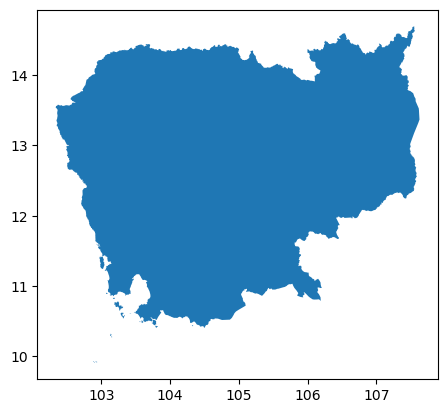

In [9]:
#Country shapefile
KHM=gpd.read_file(r"C:\Users\laura\Vestigium Métodos Mixtos Aplicados SAS\MMC - General - SIG\DISES\data\KHM\country_bounds.shp")
KHM.plot()

#Transform coordinates
KHM = KHM.to_crs(gdf.crs)
print(KHM.crs)

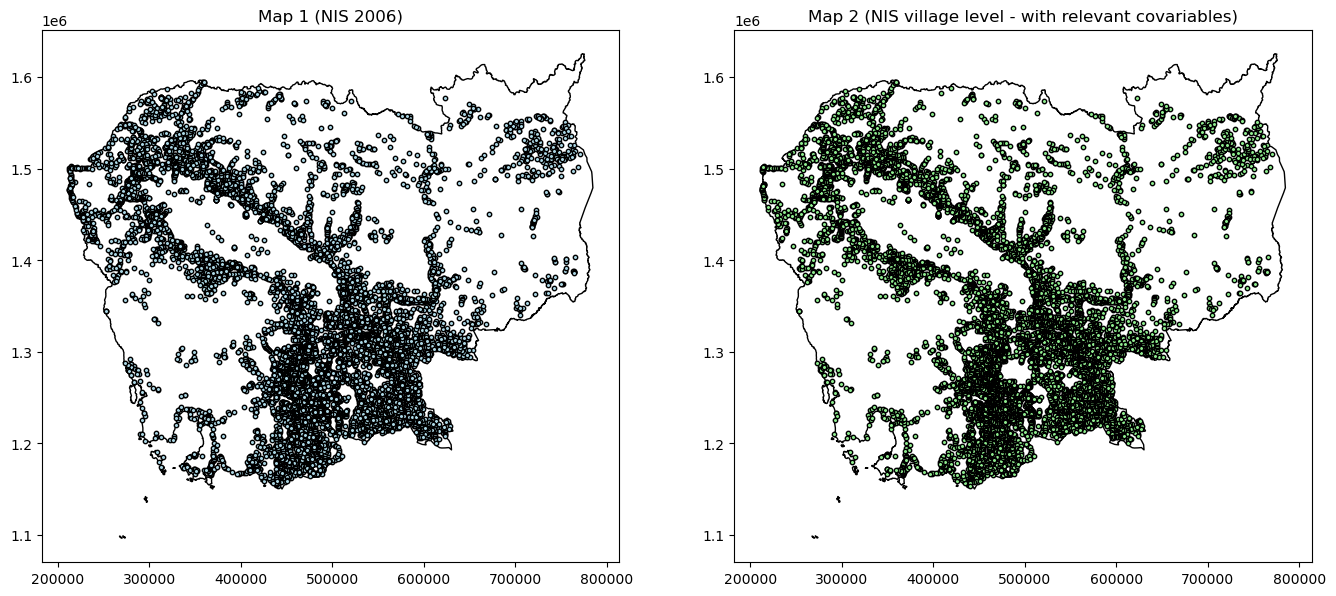

In [10]:

# Comparison map of geographic unities
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

#Map 1: NIS geographical units
KHM.plot(ax=axes[0], facecolor='white', edgecolor='black', alpha=1)
nis06.plot(ax=axes[0], color='lightblue', edgecolor='black', markersize=10)
axes[0].set_title('Map 1 (NIS 2006)')

#Map 2: Geographical units after relevant covariable selection
KHM.plot(ax=axes[1], facecolor='white', edgecolor='black', alpha=1)
gdf.plot(ax=axes[1], color='lightgreen', edgecolor='black', markersize=10)
axes[1].set_title('Map 2 (NIS village level - with relevant covariables)')

plt.tight_layout()
plt.show()


In [11]:
#Check for NA's in relevant covariates
gdf.isna().sum()

rate_nutr     11698
geometry          0
grid_id           0
523-C_MORT        0
534-LQ_ROO        0
517-UNIMPR        0
pa_binary         0
slope             0
northness         0
wealth_200        0
y2004_STme        0
y2005_STme        0
pobcount20        0
%crops            0
%builtarea        0
%baregnd          0
NPP_10_23         0
EVI_10_23         0
n_ducks           0
dtype: int64

In [12]:
gdf.columns.tolist()

['rate_nutr',
 'geometry',
 'grid_id',
 '523-C_MORT',
 '534-LQ_ROO',
 '517-UNIMPR',
 'pa_binary',
 'slope',
 'northness',
 'wealth_200',
 'y2004_STme',
 'y2005_STme',
 'pobcount20',
 '%crops',
 '%builtarea',
 '%baregnd',
 'NPP_10_23',
 'EVI_10_23',
 'n_ducks']

### Data selection for model training

In [13]:
# Data will be segmented into two parts:
    # 1. train_data: For training the model with relevant covariates selected by lasso and observations that have the target variable [rate_nutr], in other words, observations that have complete information.
    # 2. predict_data: Observations that do not have the target variable [rate_nutr], but do have relevant covariates. 

train_data = gdf[gdf["rate_nutr"].notnull()].copy()
predict_data = gdf[gdf["rate_nutr"].isnull()].copy()


In [14]:
#Export train data to shapefile if relevant
train_data.to_file(r"C:\Users\laura\Vestigium Métodos Mixtos Aplicados SAS\Daniel Wiesner - DISES\SAE\SAE - Nutrition\output\Train data\traindata_SAEnutr.shp", driver='ESRI Shapefile')

In [15]:
print(f"Number of observations in train_data: {len(train_data)}")
print(f"Number of observations in predict_data: {len(predict_data)}")

Number of observations in train_data: 378
Number of observations in predict_data: 11698


In [16]:
train_data.columns.to_list

<bound method IndexOpsMixin.tolist of Index(['rate_nutr', 'geometry', 'grid_id', '523-C_MORT', '534-LQ_ROO',
       '517-UNIMPR', 'pa_binary', 'slope', 'northness', 'wealth_200',
       'y2004_STme', 'y2005_STme', 'pobcount20', '%crops', '%builtarea',
       '%baregnd', 'NPP_10_23', 'EVI_10_23', 'n_ducks'],
      dtype='object')>

In [17]:
# For training the model, the predictor variables (X) and the target variable (y - rate_nutr) will be defined:
X = train_data.drop(columns=["rate_nutr", "geometry", "grid_id"])  # Elimination of variables that aren't predictors
y = train_data["rate_nutr"]

#List of predictor variables:
X_columns = X.columns
print(f"List of predictor variables:{X.columns.tolist()}")

List of predictor variables:['523-C_MORT', '534-LQ_ROO', '517-UNIMPR', 'pa_binary', 'slope', 'northness', 'wealth_200', 'y2004_STme', 'y2005_STme', 'pobcount20', '%crops', '%builtarea', '%baregnd', 'NPP_10_23', 'EVI_10_23', 'n_ducks']


Text(0.5, 1.0, 'Observations with complete data')

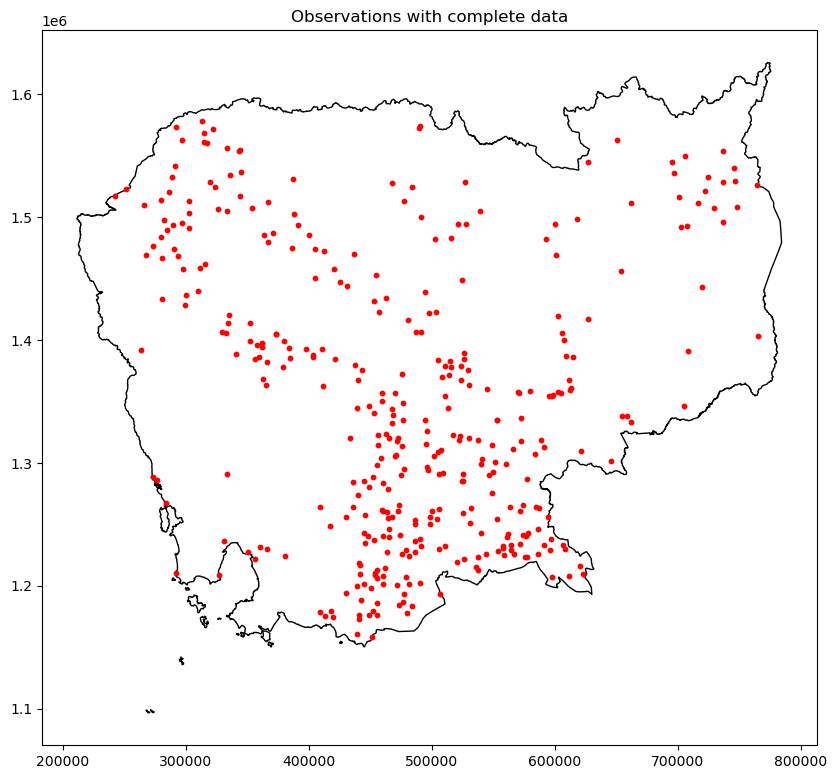

In [18]:
# Create a plot for observations with complete data [train_data]
fig, ax = plt.subplots(figsize=(10, 10))


KHM.plot(ax=ax, color='white', edgecolor='black')
#gdf.plot(ax=ax, color='blue', markersize=5) #Complete observations
train_data.plot(ax=ax, color='red', markersize=10)
ax.set_title(f'Observations with complete data')


### OLS and Moran's I

#### OLS Model
- Fits a baseline Ordinary Least Squares (OLS) regression model using the selected covariates to predict nutrition rates.
- Computes the residuals from the OLS model (observed minus predicted) for the selected data. These residuals are used to visualize anf provide hints of posible spatial autocorrelation. 
- If there is evidence of spatial autocorrelation by identifying spatial patterns in the OLS model residuals map, then Moran's I should be performed to check or reject spatial autocorrelation in the data and, if present, an Spatial Error Model (SEM) should be considered.

In [19]:
#OLS Model
ols = LinearRegression()
ols.fit(X, y)
y_predOLS = ols.predict(X)
residuals = y - y_predOLS

##### OLS predictions

In [20]:
linreg = LinearRegression().fit(X, y)
X_columns_OLS = X.columns.tolist()

gdf["y_pred_ols"] = linreg.predict(gdf[X_columns_OLS])

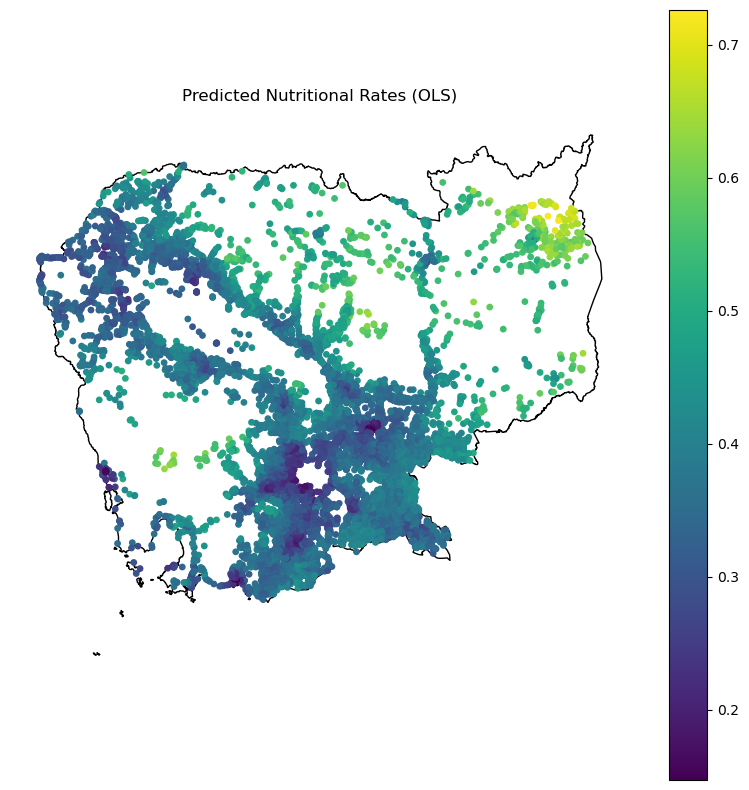

In [21]:
# Visualize predictions with OLS
fig, ax = plt.subplots(figsize=(10, 10))
KHM.plot(ax=ax, facecolor='white', edgecolor='black', alpha=1)
gdf.plot(column='y_pred_ols', cmap='viridis',markersize=15, legend=True, ax=ax)   
plt.title('Predicted Nutritional Rates (OLS)')
plt.axis('off')
plt.show()


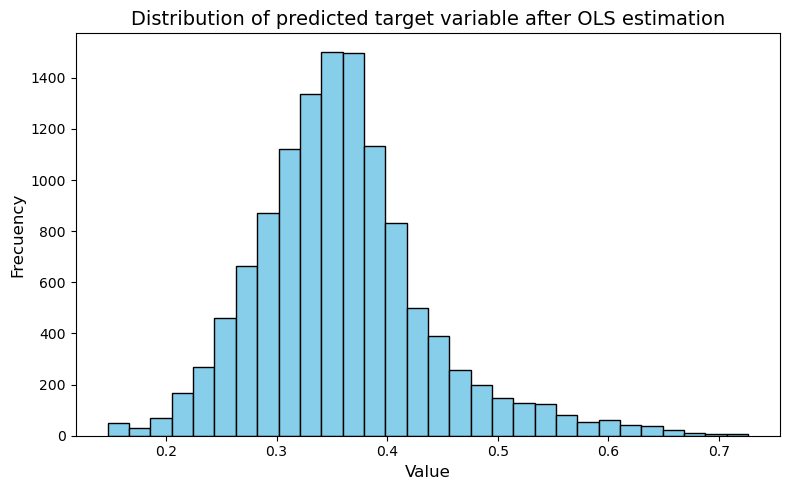

In [22]:
plt.figure(figsize=(8, 5)) 
plt.hist(gdf['y_pred_ols'], bins=30, color='skyblue', edgecolor='black')

plt.title('Distribution of predicted target variable after OLS estimation', fontsize=14)
plt.xlabel('Value', fontsize=12)
plt.ylabel('Frecuency', fontsize=12)


plt.tight_layout()
plt.show()

In [23]:
gdf["y_pred_ols"].describe()

count    12076.000000
mean         0.359086
std          0.079147
min          0.147290
25%          0.308695
50%          0.353363
75%          0.395793
max          0.726182
Name: y_pred_ols, dtype: float64

##### OLS model

In [24]:

X_const = sm.add_constant(X)
model = sm.OLS(y, X_const).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:              rate_nutr   R-squared:                       0.274
Model:                            OLS   Adj. R-squared:                  0.242
Method:                 Least Squares   F-statistic:                     8.508
Date:                Mon, 28 Jul 2025   Prob (F-statistic):           1.53e-17
Time:                        08:51:50   Log-Likelihood:                 186.72
No. Observations:                 378   AIC:                            -339.4
Df Residuals:                     361   BIC:                            -272.5
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.9264      0.252      3.669      0.0

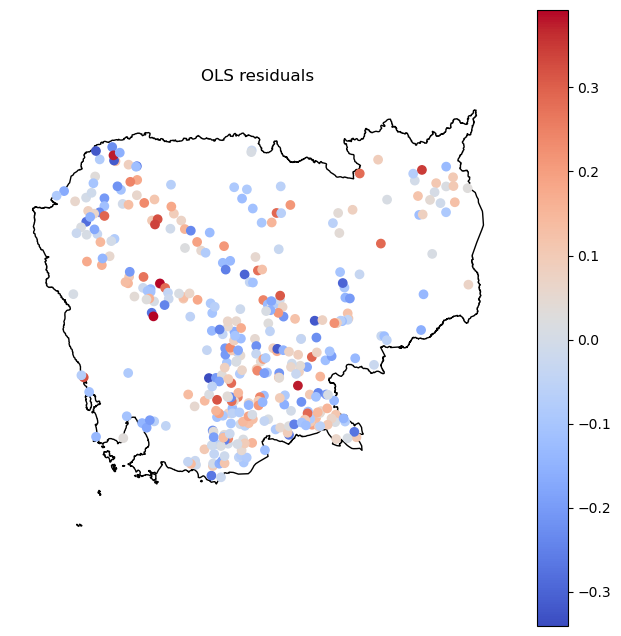

In [25]:
train_data["residuals"] = residuals
fig, ax = plt.subplots(figsize=(8, 8))
KHM.plot(ax=ax, color='white', edgecolor='black')
train_data.plot(column="residuals", cmap="coolwarm", legend=True, ax=ax)
plt.title("OLS residuals")
plt.axis("off")
plt.show()

# There are spatial patterns in the residual and there's no error independence, so the OLS model is not appropriate for the estimation of the target variable. 

#### Moran's I (to test spatial autocorrelation)
Moran's I 

Given the presence of spatial patterns in the residuals of the OLS model (map above), it's necessary to apply Moran's I test to formally confirm the existence of spatial autocorrelation. Moran's I is a widely used global measure of spatial dependence and is particularly effective when applied to regression residuals to detect potential model misspecification due to spatial effects (Anselin, 1988; LeSage & Pace, 2009). However, this test requires an **spatial weight matrix** which is related to the notion of proximity between geographic units, and plays an important role in describing the structure of these processes because the measure of spatial dependence itself can vary with a different choice of spatial weight matrix. Since the dataset comprises spatially dispersed centroids rather than contiguous areal units, traditional contiguity-based spatial weights are not appropriate. Instead, k-nearest neighbor (KNN) and distance threshold matrices provide more flexible and consistent criteria to define spatial relationships under these conditions (Anselin, 2005; LeSage & Pace, 2009). Although there is no consensus on the “best” method to construct a spatial weights matrix, using KNN or fixed-distance thresholds is recommended in such contexts, as these approaches ensure that all observations are connected while preserving meaningful spatial structure for diagnostics and modeling.

**Interpretation of Moran's I:**
- A significant Moran's I (closer to 1) indicates spatial autocorrelation in residuals.
- This suggests model misspecification (e.g., omitted spatial effects).

**Sources:**

- Anselin, L. (1988). Spatial Econometrics: Methods and Models. Springer.

- Anselin, L. (2005). Exploring Spatial Data with GeoDa: A Workbook.

- LeSage, J., & Pace, R. K. (2009). Introduction to Spatial Econometrics. CRC Press.

##### KNN weight matrix: 
In spatial analysis, ***k-nearest neighbors (KNN)*** is a method used to construct a spatial weights matrix by connecting each observation (e.g., geographic unit or centroid) to its k closest neighbors in space, based on Euclidean distance. This ensures that all observations are connected to a fixed number of neighbors, which is particularly useful when data are irregularly distributed or not based on contiguous polygons. A parameter "k" is needed and choosing it appropiately is key for the construction of the spatial weight matrix. A correct interpretation for k is the number of nearest spatial neighbors to which each observation is connected.

c:\Users\laura\anaconda3\envs\rasters\Lib\site-packages\libpysal\weights\distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 117 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)
c:\Users\laura\anaconda3\envs\rasters\Lib\site-packages\libpysal\weights\distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 23 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)
c:\Users\laura\anaconda3\envs\rasters\Lib\site-packages\libpysal\weights\distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 5 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)
c:\Users\laura\anaconda3\envs\rasters\Lib\site-packages\libpysal\weights\distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 2 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)


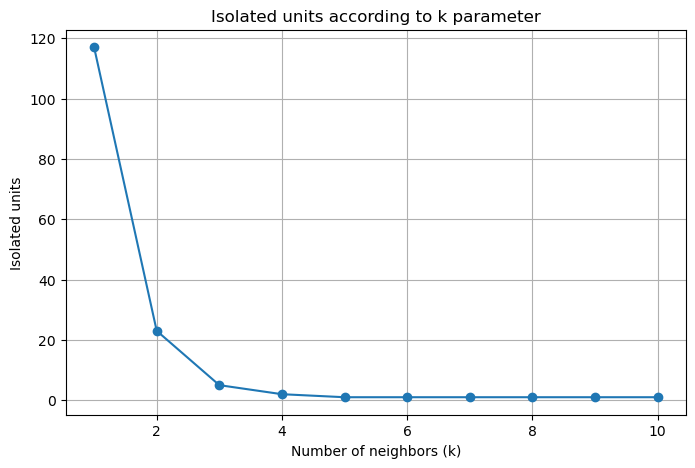

In [26]:
# Loop through different values of "k" (from 1 to 10)
# Display information of how many geographical units are isolated (not recommended) at each level of k.

component_counts = {}

for k in range(1, 11):
    w = KNN.from_dataframe(train_data, k=k)
    # We get labels of connected components
    labels = w.component_labels
    # Number of different components
    n_components = len(set(labels))
    component_counts[k] = n_components

# Plot
plt.figure(figsize=(8, 5))
plt.plot(list(component_counts.keys()), list(component_counts.values()), marker='o')
plt.xlabel("Number of neighbors (k)")
plt.ylabel("Isolated units")
plt.title("Isolated units according to k parameter")
plt.grid(True)
plt.show()

#The graph shows the ideal k is where no geographical units are isolated, according to the plot k=5.

In [27]:

# Function to find the ideal k

# The funcion searches for the smallest value of k for which all observations are connected at least to one unit and there aren't isolated units.

def ideal_k(gdf, k_max=20):
    for k in range(1, k_max + 1):
        w = KNN.from_dataframe(gdf, k=k)
        labels = w.component_labels
        n_components = len(set(labels))
        
        isolated_units = any(len(neigh) == 0 for neigh in w.neighbors.values())
        
        if n_components == 1 and not isolated_units:
            print(f"*Ideal k parameter:* {k}")
            return k
        else:
            print(f"k={k} isolated units: {n_components}")
    
    print("There is no ideal k parameter found within the specified range.")
    return None

# Use the function:
ideal_k = ideal_k(train_data)


k=1 isolated units: 117
k=2 isolated units: 23
k=3 isolated units: 5
k=4 isolated units: 2
*Ideal k parameter:* 5


In [28]:
# Build spatial weight matrix - KNN [each unit has 5 nearest neighbors with  no isolation among observations]

# In the spatial weight matrix 1 (neighbor) would indicate if the geographical unit is one of the 5 nearest neighbors of the row unit. While 0 indicates that the geographical unit isn't a neighbor.

coords = train_data.geometry.centroid.apply(lambda geom: (geom.x, geom.y)).tolist()
w_knn = KNN.from_array(coords, k=5)
w_knn.transform = 'r'

#Calculate Moran's I for the residuals using the KNN weights
moran_knn = Moran(residuals, w_knn)

print("Moran's I using KNN (k=5):")
print(f"Moran's I: {moran_knn.I:.4f}")
print(f"p-value (simulation): {moran_knn.p_sim:.4f}")

# The results via KNN don't indicate spatial autocorrelation, the neighbor units don't tend to have similar values of their variables. Also it indicates that the residuals of the OLS model aren't  spatially autocorrelated. 

Moran's I using KNN (k=5):
Moran's I: 0.0142
p-value (simulation): 0.3010


##### Distance - based weight matrix

In spatial analysis, the ***distance cut-off (or distance threshold)*** criteria defines neighbors for a spatial weights matrix based on whether they lie within a specified maximum distance from one another. Two units are considered neighbors if the Euclidean distance between them is less than or equal to a fixed threshold. This approach is especially useful for point data and irregular spatial layouts, ensuring meaningful proximity-based spatial relationships (Anselin, 1988; Anselin, 2005; LeSage & Pace, 2009).



In [29]:
#Find the minimum distance that guarantees connectivity between units (no isolated geographical units)

# Extract the coordinates of the centroids from the geometry column
coords_1 = np.array(train_data.geometry.centroid.apply(lambda geom: (geom.x, geom.y)).tolist())

# Calculate distance matrix
dist_matrix = distance_matrix(coords_1, coords_1)

# Replace diagonal with infinity (to avoid self-distance)
np.fill_diagonal(dist_matrix, np.inf)

# For each point, find the distance to its nearest neighbor
min_dist_per_unit = dist_matrix.min(axis=1)

# The smallest distance threshold that ensures all units have at least one neighbor
# is the maximum among all units minimum distances to any other unit
threshold_min = min_dist_per_unit.max()

print(f"Minimum distance that guarantees connectivity: {threshold_min:.2f} meters")


Minimum distance that guarantees connectivity: 58377.98 meters


In [30]:
# Build spatial weight matrix - Distance -based [A unit is connected to all others within 58,377.98 meters (58 km)]
w_dist_train = DistanceBand(coords, threshold=58377.98, binary=True, silence_warnings=True)
w_dist_train.transform = 'r'

# Calculate Moran's I using the distance weights

# In the spatial weight matrix 1 (neighbor) would indicate if the geographical unit is within 58km of distance. While 0 indicates that the geographical unit isn't a neighbor (over 58km of distance).

moran_dist = Moran(residuals, w_dist_train)

print("Moran's I using distance (threshold = 58 km)")
print(f"Moran's I: {moran_dist.I:.4f}")
print(f"p-value (simulation): {moran_dist.p_sim:.4f}")

# The results via distance don't indicate spatial autocorrelation, the neighbor units don't tend to have similar values of their variables. Also it indicates that the residuals of the OLS model aren't spatially autocorrelated. 


Moran's I using distance (threshold = 58 km)
Moran's I: 0.0217
p-value (simulation): 0.0680


### Spatial Error Model (SEM) 

The Spatial Error Model (SEM) is a regression model that accounts for spatial autocorrelation in the error term. It assumes that unobserved spatial processes affect the outcome through the error structure, not directly through the dependent variable. **This model is chosen if, after the results of Moran's I test on OLS residuals, is proven a significant spatial autocorrelation, because it suggests that important spatial effects have been omitted.** The SEM corrects for this by explicitly modeling the spatial structure in the residuals, improving inference and preventing biased or inefficient estimates. It's relevant to mention that the SEM relies on a spatial weights matrix to define the structure of spatial dependence among the error terms, making the choice of weights a critical part of model specification.

In this section, two SEM models will be specified with different criteria already specified for the construction of the weight matrix (KNN and distance weight) to select the model with the best performance based on the Moran's I, RSME and r-squared criteria.


#### SEM (KNN)

In [31]:

X_array = X.values
y_array = y.values.reshape(-1, 1)

# SEM (Spatial Error Model) - KNN Weight Matrix
model_sem_knn = GM_Error(y_array, X_array, w=w_knn, name_y='rate_nutr', name_x=X.columns.tolist())

print(model_sem_knn.summary)

REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: GM SPATIALLY WEIGHTED LEAST SQUARES
------------------------------------------------------
Data set            :     unknown
Weights matrix      :     unknown
Dependent Variable  :   rate_nutr                Number of Observations:         378
Mean dependent var  :      0.3799                Number of Variables   :          17
S.D. dependent var  :      0.1735                Degrees of Freedom    :         361
Pseudo R-squared    :      0.2737

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
------------------------------------------------------------------------------------
            CONSTANT         0.93429         0.25017         3.73469         0.00019
          523-C_MORT        -0.01413         0.04469        -0.31610         0.75192
          534-LQ_ROO        -0.01057         0.02551        -0.41419

#### SEM (Distance-based)

In [32]:
# SEM (Spatial Error Model) - Distance (<58km) Weights
model_sem_dist = GM_Error(y_array, X_array, w=w_dist_train, name_y='rate_nutr', name_x=X.columns.tolist())

print(model_sem_dist.summary)

REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: GM SPATIALLY WEIGHTED LEAST SQUARES
------------------------------------------------------
Data set            :     unknown
Weights matrix      :     unknown
Dependent Variable  :   rate_nutr                Number of Observations:         378
Mean dependent var  :      0.3799                Number of Variables   :          17
S.D. dependent var  :      0.1735                Degrees of Freedom    :         361
Pseudo R-squared    :      0.2733

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
------------------------------------------------------------------------------------
            CONSTANT         0.94413         0.25389         3.71860         0.00020
          523-C_MORT        -0.01752         0.04539        -0.38610         0.69943
          534-LQ_ROO        -0.01051         0.02542        -0.41350

In [33]:
# Calculate RMSE for both SEM models
rmse_knn = np.sqrt(mean_squared_error(y, model_sem_knn.predy))
rmse_dist = np.sqrt(mean_squared_error(y, model_sem_dist.predy))
print(f"RMSE SEM with KNN matrix: {rmse_knn:.5f}")
print(f"RMSE SEM with distance matrix: {rmse_dist:.5f}")

RMSE SEM with KNN matrix: 0.14766
RMSE SEM with distance matrix: 0.14773


In [34]:
# Calculate R-squared for both SEM models
#KNN  Residuals
residuals_sem_knn = y.values.flatten() - model_sem_knn.predy.flatten()
moran_resid_knn = Moran(residuals_sem_knn, w_knn)  
print(f"Moran's I in SEM residuals (KNN): {moran_resid_knn.I:.4f}, p={moran_resid_knn.p_sim:.4f}")

#Distance Residuals
residuals_sem_dist = y.values.flatten() - model_sem_dist.predy.flatten()
moran_resid_dist = Moran(residuals_sem_dist, w_dist_train)
print(f"Moran's I in SEM residuals (Distance): {moran_resid_dist.I:.4f}, p={moran_resid_dist.p_sim:.4f}")

Moran's I in SEM residuals (KNN): 0.0170, p=0.2660
Moran's I in SEM residuals (Distance): 0.0273, p=0.0430


#### Model comparison KNN vs. Distance SEM: 

| Criterion                 | SEM (KNN, k=5) | SEM (Distance, 58 km) | Selection criteria |
|---------------------------|----------------:|-----------------------:|:----------|
| **RMSE**                  | **0.14766**          | 0.14773             |  Lower error indicates better predictive accuracy |
| **Moran’s I (residuals)** | **0.0170 (p = 0.2410)** | 0.0273 (p = 0.0350) |  Closer to zero implies weaker spatial autocorrelation in residuals |
| **R²**             | **0.2737**        | 0.2733            |  Higher value indicates better explanatory power |

---

**Conclusion**: KNN SEM is slightly better. 


### Apply   KNN Weight SEM model for predicting target variable

In [35]:
model_columns = ['523-C_MORT', '534-LQ_ROO', '517-UNIMPR', 'pa_binary', 'slope', 'northness', 'wealth_200', 'y2004_STme', 'y2005_STme', 'pobcount20', '%crops', '%builtarea', '%baregnd', 'NPP_10_23', 'EVI_10_23', 'n_ducks']

#### Redefine spatial weight matrix for all observations

##### Distance - based 

In [36]:
#Find the minimum distance that guarantees connectivity between units (no isolated geographical units)


# Extract the coordinates of the centroids from the geometry column
coords_1 = np.array(gdf.geometry.centroid.apply(lambda geom: (geom.x, geom.y)).tolist())

# Calculate distance matrix
dist_matrix = distance_matrix(coords_1, coords_1)

# Replace diagonal with infinity (to avoid self-distance)
np.fill_diagonal(dist_matrix, np.inf)

# For each point, find the distance to its nearest neighbor
min_dist_per_unit = dist_matrix.min(axis=1)

# The smallest distance threshold that ensures all units have at least one neighbor
# is the maximum among all units minimum distances to any other unit
threshold_min = min_dist_per_unit.max()

print(f"Minimum distance that guarantees connectivity: {threshold_min:.2f} meters")


Minimum distance that guarantees connectivity: 25142.17 meters


In [37]:
#New distance based weights matrix for the all  observations
coords_all = gdf.geometry.centroid.apply(lambda p: (p.x, p.y)).to_list()
w_dist_all = DistanceBand(coords_all, threshold=25142.17, binary=True, silence_warnings=True)
w_dist_all.transform = 'r'


##### KNN Spatial Weight Matrix

c:\Users\laura\anaconda3\envs\rasters\Lib\site-packages\libpysal\weights\distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 3659 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)
c:\Users\laura\anaconda3\envs\rasters\Lib\site-packages\libpysal\weights\distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 622 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)
c:\Users\laura\anaconda3\envs\rasters\Lib\site-packages\libpysal\weights\distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 102 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)
c:\Users\laura\anaconda3\envs\rasters\Lib\site-packages\libpysal\weights\distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 27 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)
c:\Users\laura\anaconda3\envs\raster

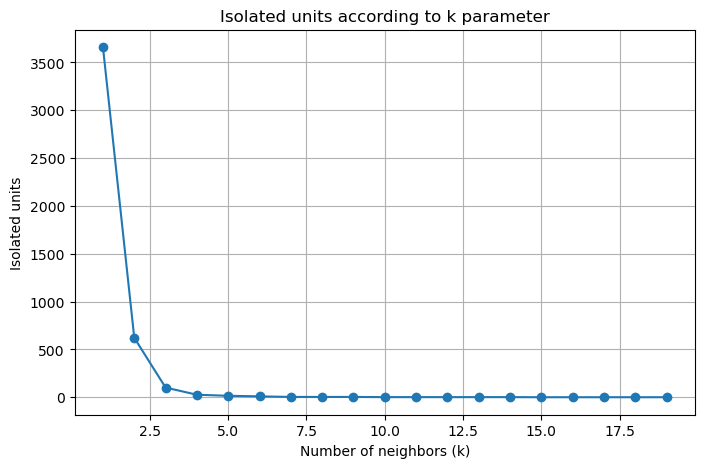

In [38]:
# Loop through different values of "k" (from 1 to 20)
# Display information of how many geographical units are isolated (not recommended) at each level of k.

component_counts = {}

for k in range(1, 20):
    w = KNN.from_dataframe(gdf, k=k)
    # We get labels of connected components
    labels = w.component_labels
    # Number of different components
    n_components = len(set(labels))
    component_counts[k] = n_components

# Plot
plt.figure(figsize=(8, 5))
plt.plot(list(component_counts.keys()), list(component_counts.values()), marker='o')
plt.xlabel("Number of neighbors (k)")
plt.ylabel("Isolated units")
plt.title("Isolated units according to k parameter")
plt.grid(True)
plt.show()

#The graph shows the ideal k is where no geographical units are isolated, according to the plot k=5.

In [39]:

# Function to find the ideal k for all data 

# The funcion searches for the smallest value of k for which all observations are connected at least to one unit and there aren't isolated units.

def ideal_k(gdf, k_max=20):
    for k in range(1, k_max + 1):
        w = KNN.from_dataframe(gdf, k=k)
        labels = w.component_labels
        n_components = len(set(labels))
        
        isolated_units = any(len(neigh) == 0 for neigh in w.neighbors.values())
        
        if n_components == 1 and not isolated_units:
            print(f"*Ideal k parameter:* {k}")
            return k
        else:
            print(f"k={k} isolated units: {n_components}")
    
    print("There is no ideal k parameter found within the specified range.")
    return None

# Use the function:
ideal_k = ideal_k(gdf)

k=1 isolated units: 3659
k=2 isolated units: 622
k=3 isolated units: 102
k=4 isolated units: 27
k=5 isolated units: 16
k=6 isolated units: 10
k=7 isolated units: 4
k=8 isolated units: 4
k=9 isolated units: 4
k=10 isolated units: 2
k=11 isolated units: 2
k=12 isolated units: 2
k=13 isolated units: 2
k=14 isolated units: 2
*Ideal k parameter:* 15


In [40]:
# Spatials weights matrix - KNN [each unit has 15 nearest neighbors with no isolation among all observations]
w_knn_all = KNN.from_array(coords_all, k=15)
w_knn_all.transform = 'r'

##### Predictions with SEM (KNN)

###### SEM - KNN (alone)

In [41]:
# Filter valid columns that really are in gdf (without constant and lambda)
model_columns_clean = [col for col in model_sem_knn.name_x if col in gdf.columns and col.lower() != 'lambda' and col.lower() != 'constant']
print(f"Model columns: {model_columns}")

Model columns: ['523-C_MORT', '534-LQ_ROO', '517-UNIMPR', 'pa_binary', 'slope', 'northness', 'wealth_200', 'y2004_STme', 'y2005_STme', 'pobcount20', '%crops', '%builtarea', '%baregnd', 'NPP_10_23', 'EVI_10_23', 'n_ducks']


In [42]:
X_all_array = gdf[model_columns_clean].values
theta = np.array(model_sem_knn.betas[1:-1]).flatten() 
intercept = model_sem_knn.betas[0][0]

rate_nutr_predicted_sem_only = X_all_array @ theta + intercept

# Add to GeoDataFrame
gdf['rate_nutr_predicted_sem_only'] = rate_nutr_predicted_sem_only



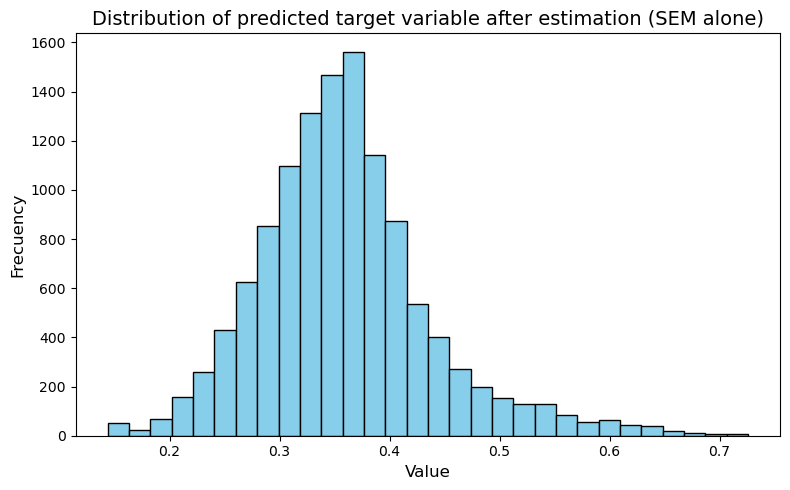

count    12076.000000
mean         0.358884
std          0.079476
min          0.143808
25%          0.308569
50%          0.353338
75%          0.396149
max          0.725893
Name: rate_nutr_predicted_sem_only, dtype: float64


In [43]:
# Visualize predictions
plt.figure(figsize=(8, 5)) 
plt.hist(gdf['rate_nutr_predicted_sem_only'], bins=30, color='skyblue', edgecolor='black')

plt.title('Distribution of predicted target variable after estimation (SEM alone)', fontsize=14)
plt.xlabel('Value', fontsize=12)
plt.ylabel('Frecuency', fontsize=12)


plt.tight_layout()
plt.show()

print(gdf['rate_nutr_predicted_sem_only'].describe())

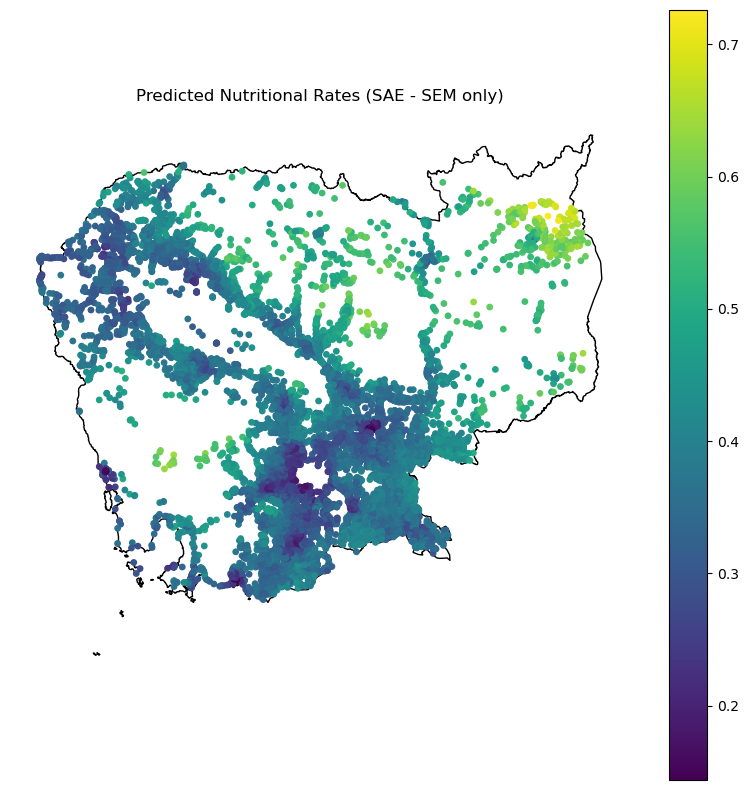

In [44]:

fig, ax = plt.subplots(figsize=(10, 10))
KHM.plot(ax=ax, facecolor='white', edgecolor='black', alpha=1)
gdf.plot(column='rate_nutr_predicted_sem_only', cmap='viridis',markersize=15, legend=True, ax=ax)   
plt.title('Predicted Nutritional Rates (SAE - SEM only)')
plt.axis('off')
plt.show()

###### SEM - KNN + BLUP  (as paper)

From Van der Weide & Elbers (2022), for this type of estimations using SEM alone gives a linear predictor that accounts for spatial autocorrelation, but does not optimally combine the observed and predicted information for unsampled areas.

Adding the BLUP adjustment (Best Linear Unbiased Prediction) incorporates the residual structure and spatial correlation to produce statistically efficient predictions, especially for out-of-sample (unobserved) areas. 

SEM + BLUP Prediction Equation

The final prediction for an out-of-sample unit is:
\[
\hat{q}_O = m_O + \Sigma_{OS}(\Sigma_{SS} + D_S)^{-1}(q_S - m_S)
\]

Where:
- \( \hat{q}_O \): Final prediction for out-of-sample areas
- \( m_O \): Linear SEM prediction for out-of-sample units
- \( q_S \): Observed values in in-sample areas
- \( m_S \): SEM prediction for in-sample units
- \( \Sigma_{OS} \): Covariance between out-of-sample and in-sample areas
- \( \Sigma_{SS} \): Covariance among in-sample areas
- \( D_S \): Diagonal matrix with residual variance \( \sigma^2_\epsilon \)

> The BLUP adjustment leverages spatial correlation in residuals to **improve local prediction accuracy**, beyond what SEM alone can offer. In other words, we start with the SEM prediction and adjust it using spatial information from the residuals of nearby observed villages, improving accuracy and reducing variance.

In [45]:

# 1. Covariable extraction from complete dataset (gdf) and division of observed (S) and not observed (O) target variable
gdf['in_sample'] = gdf['rate_nutr'].notna()

# 2. Extract covariates for all observations (X_all) and split into in-sample (X_S) and out-of-sample (X_O)
X_all = gdf[model_columns].copy()
print(f"Number of columns in X_all: {X_all.shape[1]}")
X_all_array = X_all.values

X_S = X_all_array[gdf['in_sample'].values]
X_O = X_all_array[~gdf['in_sample'].values]

#3. Record sizes

n_all = X_all_array.shape[0]
n_S = X_S.shape[0]
n_O = X_O.shape[0]

# 4. Check for missing values in the covariates
print(f"Missing values in X_all:\n{X_all.isna().sum()}")

# 5. Predict using SEM model coefficients (excluding lambda)
beta = model_sem_knn.betas.flatten()
m_all = X_all_array @ beta[1:17] + beta[0] #predicted mean from SEM
m_S = m_all[gdf['in_sample'].values]
m_O = m_all[~gdf['in_sample'].values]

# 5. Predict using SEM model coefficients (excluding lambda)
q_hat_S = gdf.loc[gdf['in_sample'], 'rate_nutr'].values

# 7. Calculate residuals for in-sample observations
residuals_S = q_hat_S - m_S 


Number of columns in X_all: 16
Missing values in X_all:
523-C_MORT    0
534-LQ_ROO    0
517-UNIMPR    0
pa_binary     0
slope         0
northness     0
wealth_200    0
y2004_STme    0
y2005_STme    0
pobcount20    0
%crops        0
%builtarea    0
%baregnd      0
NPP_10_23     0
EVI_10_23     0
n_ducks       0
dtype: int64


In [46]:

# 1. Extract lambda and spatial weights matrix W
lam = model_sem_knn.vm[1][-1]
W = w_knn_all.sparse  # spatial weight matrix (sparse format because it consumes a huge amount of memory)
n_all = W.shape[0]

# 2. Define A = (I - λW), used in solving for Σ matrices
def matvec_A(x):
    return x - lam * W @ x

A_op = LinearOperator((n_all, n_all), matvec=matvec_A, dtype='float64')

# 3. Index positions for in sample and out of sample observations
idx_S = np.where(gdf['in_sample'].values)[0]
idx_O = np.where(~gdf['in_sample'].values)[0]
n_S = len(idx_S)
n_O = len(idx_O)

# 4. Initialization of Sigma matrices (spatial covariance matrices)
Sigma_SS = np.zeros((n_S, n_S))
Sigma_OS = np.zeros((n_O, n_S))

from tqdm import tqdm  

# 5. Solve (I - λW)^-1 * e_j for each unit j to construct Sigma matrices
for j, col_idx in enumerate(tqdm(idx_S, desc="Solving linear systems")):
    e_j = np.zeros(n_all)
    e_j[col_idx] = 1
    x_j, info = cg(A_op, e_j, atol=1e-6)
    Sigma_SS[:, j] = x_j[idx_S]
    Sigma_OS[:, j] = x_j[idx_O]

# 6. Compute error variance and apply BLUP adjustment
var_eps = np.var(model_sem_knn.u)
D_S = np.eye(n_S) * var_eps
adj = Sigma_OS @ dense_inv(Sigma_SS + D_S) @ residuals_S
adj_S = Sigma_SS @ dense_inv(Sigma_SS + D_S) @ residuals_S
q_hat_S_blup = m_S + adj_S
q_hat_O = m_O + adj

# 7. Join predicted values to  gdf 
rate_nutr_predicted = np.empty(n_all)
rate_nutr_predicted[idx_S] = q_hat_S_blup
rate_nutr_predicted[idx_O] = q_hat_O # Use BLUP for out of sample
gdf['rate_nutr_predicted_SEM'] = rate_nutr_predicted


Solving linear systems: 100%|██████████| 378/378 [00:00<00:00, 552.18it/s]


In [47]:
gdf.columns

Index(['rate_nutr', 'geometry', 'grid_id', '523-C_MORT', '534-LQ_ROO',
       '517-UNIMPR', 'pa_binary', 'slope', 'northness', 'wealth_200',
       'y2004_STme', 'y2005_STme', 'pobcount20', '%crops', '%builtarea',
       '%baregnd', 'NPP_10_23', 'EVI_10_23', 'n_ducks', 'y_pred_ols',
       'rate_nutr_predicted_sem_only', 'in_sample', 'rate_nutr_predicted_SEM'],
      dtype='object')

In [48]:
print("X_all shape:", X_all.shape)
print("beta shape:", beta.shape)

X_all shape: (12076, 16)
beta shape: (18,)


In [49]:
# Save predictions to a new shapefile 
output_path = fr"C:\Users\laura\Vestigium Métodos Mixtos Aplicados SAS\Daniel Wiesner - DISES\SAE\SAE - Nutrition\output\sae-nis-nutrpredictions-{nis_year}.shp"
gdf.to_file(output_path, driver='ESRI Shapefile')

C:\Users\laura\AppData\Local\Temp\ipykernel_24816\1154790671.py:3: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf.to_file(output_path, driver='ESRI Shapefile')
c:\Users\laura\anaconda3\envs\rasters\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'rate_nutr_predicted_sem_only' to 'rate_nutr_'
  ogr_write(
c:\Users\laura\anaconda3\envs\rasters\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'rate_nutr_predicted_SEM' to 'rate_nut_1'
  ogr_write(


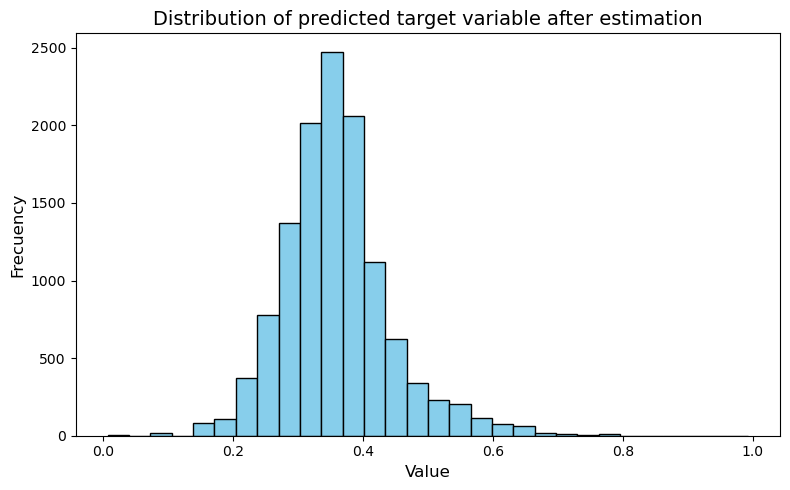

In [50]:
# Visualize predictions
plt.figure(figsize=(8, 5)) 
plt.hist(gdf['rate_nutr_predicted_SEM'], bins=30, color='skyblue', edgecolor='black')

plt.title('Distribution of predicted target variable after estimation', fontsize=14)
plt.xlabel('Value', fontsize=12)
plt.ylabel('Frecuency', fontsize=12)


plt.tight_layout()
plt.show()


In [51]:
gdf['rate_nutr_predicted_SEM'].describe()

count    12076.000000
mean         0.358884
std          0.083484
min          0.006761
25%          0.307285
50%          0.353378
75%          0.396847
max          0.992585
Name: rate_nutr_predicted_SEM, dtype: float64

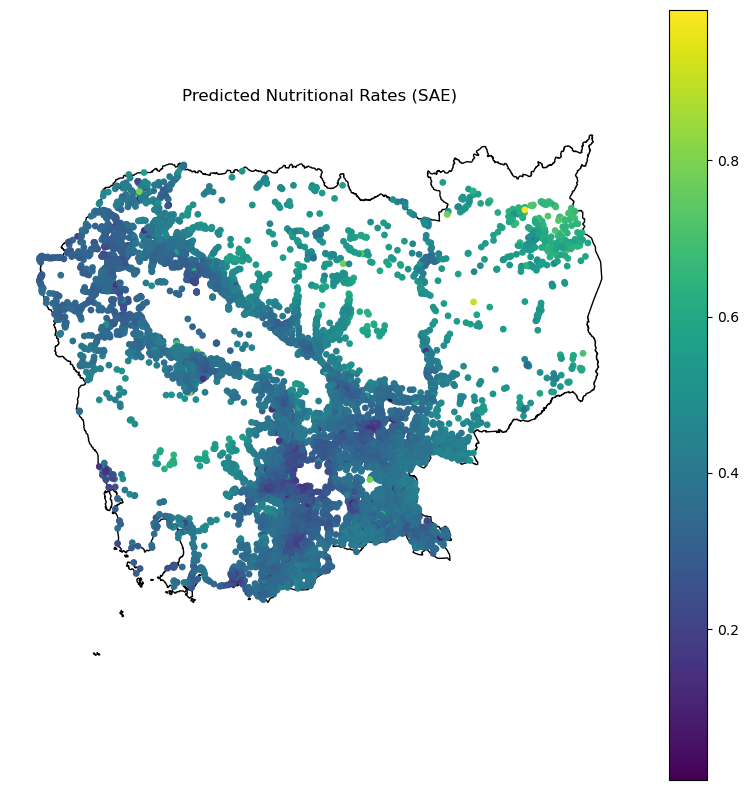

In [52]:

fig, ax = plt.subplots(figsize=(10, 10))
KHM.plot(ax=ax, facecolor='white', edgecolor='black', alpha=1)
gdf.plot(column='rate_nutr_predicted_SEM', cmap='viridis',markersize=15, legend=True, ax=ax)   
plt.title('Predicted Nutritional Rates (SAE)')
plt.axis('off')
plt.show()


### Monte Carlo Simulations

#### Interpretation of Monte Carlo Simulation for SEM Predictions

This section implements a Monte Carlo simulation to quantify uncertainty around the **predictions** from the selected model. In other words, the Monte Carlo simulation builds confidence intervals around model predictions by simulating residual noise. The original predictions are expected to lie within these intervals and should align closely with the Monte Carlo means — confirming consistency and stability in the model's predictive behavior.

##### Key points:
- The `monte_carlo_sem()` function perturbs predictions by adding noise drawn from the residual variance of the SEM model, and recomputes predictions over 1000 iterations.
- For each village, the function stores the **mean simulated prediction** and its **95% confidence interval** (2.5th [lb = lower bound] –97.5th [ub = upper bound] percentiles).


In [53]:
def monte_carlo_ols(gdf, model, X_columns, target_col="rate_nutr", iters=1000, seed=123):
    """
    Monte Carlo simulation for OLS predictions (in-sample).
    Estimates confidence intervals by simulating residual errors.

    Parameters:
    - gdf: GeoDataFrame with complete predictors and target
    - model: trained sklearn OLS model
    - X_columns: list of predictor column names
    - target_col: name of the dependent variable (must not contain NaNs)
    - iters: number of Monte Carlo simulations
    - seed: random seed

    Returns:
    - gdf: same GeoDataFrame with mean prediction and CI columns
    - sims: [iters x n] simulation matrix
    """
    np.random.seed(seed)

    # 1. Data
    y_obs = gdf[target_col].values
    X = gdf[X_columns].values
    n = len(y_obs)

    # 2. Puntual prediction and residuals
    y_pred = model.predict(X)
    residuals = y_obs - y_pred
    sigma_hat = np.std(residuals)

    # 3. Monte Carlo Simulations
    sims = np.zeros((iters, n))
    for i in range(iters):
        e_sim = np.random.normal(0, sigma_hat, size=n)
        sims[i, :] = y_pred + e_sim

    # 4. Guardar resultados
    gdf["y_pred_mc_mean"] = np.mean(sims, axis=0)
    gdf["y_pred_mc_lb"] = np.percentile(sims, 2.5, axis=0)
    gdf["y_pred_mc_ub"] = np.percentile(sims, 97.5, axis=0)

    return gdf, sims


In [54]:

linreg_ols = LinearRegression().fit(train_data[model_columns], train_data["rate_nutr"])

# Apply simulation
gdf_ols, sims_ols = monte_carlo_ols(train_data, linreg_ols, model_columns)


c:\Users\laura\anaconda3\envs\rasters\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [55]:
# Extract values
y_obs = train_data["rate_nutr"].values
y_pred = gdf_ols["y_pred_mc_mean"].values
lb = gdf_ols["y_pred_mc_lb"].values
ub = gdf_ols["y_pred_mc_ub"].values

# Calculate error bars
y_err_lower = y_pred - lb
y_err_upper = ub - y_pred


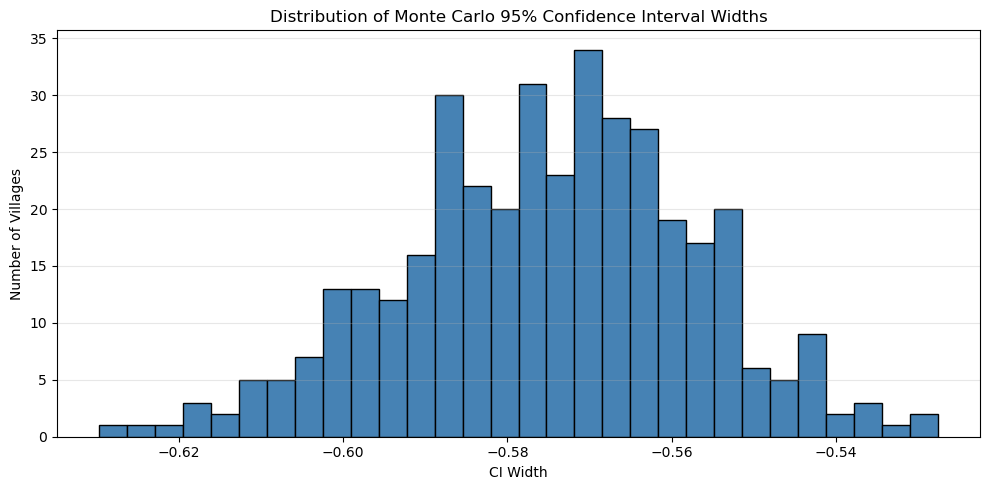

In [56]:
gdf_ols['mc_width'] = gdf_ols['y_pred_mc_lb'] - gdf_ols['y_pred_mc_ub']

plt.figure(figsize=(10, 5))
plt.hist(gdf_ols['mc_width'], bins=30, color='steelblue', edgecolor='black')
plt.title("Distribution of Monte Carlo 95% Confidence Interval Widths")
plt.xlabel("CI Width")
plt.ylabel("Number of Villages")
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

#### Visualization Insights

1. **Predicted vs Observed (In-sample)**  
   An error bar plot compares the observed values with the Monte Carlo predictions and their confidence intervals. This reveals the **uncertainty range** around each prediction and helps assess **coverage consistency**.

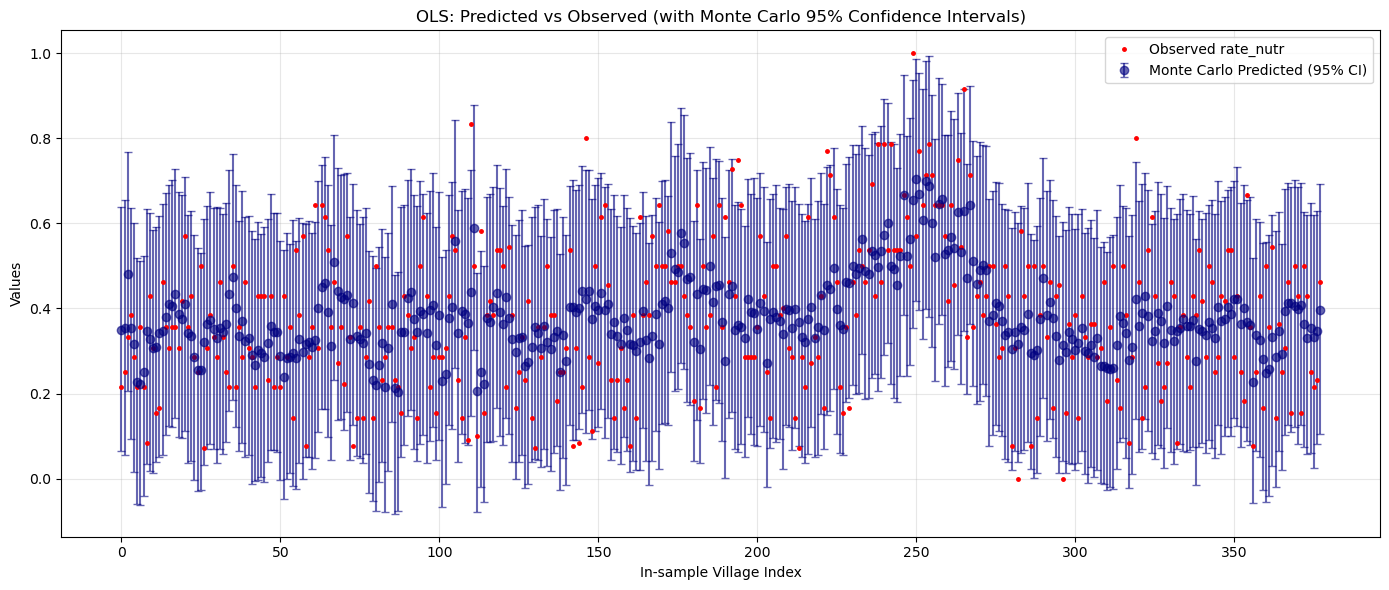

In [57]:

# Plot
plt.figure(figsize=(14, 6))
plt.errorbar(np.arange(len(y_obs)), y_pred,
             yerr=[y_err_lower, y_err_upper],
             fmt='o', alpha=0.6, capsize=3,
             label='Monte Carlo Predicted (95% CI)', color='navy')

plt.plot(np.arange(len(y_obs)), y_obs, 'r.', label='Observed rate_nutr', markersize=5)

plt.xlabel('In-sample Village Index')
plt.ylabel('Values')
plt.title('OLS: Predicted vs Observed (with Monte Carlo 95% Confidence Intervals)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



2. **Distribution Comparison (Violin Plot)**  
   The violin plot shows that both prediction approaches (Prediction and Monte Carlo mean) have slight differences in the distribution, accounting a good estimation from the trained model.


C:\Users\laura\AppData\Local\Temp\ipykernel_24816\2108573744.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Method', y='Prediction', data=df_compare, inner='box', palette='muted')


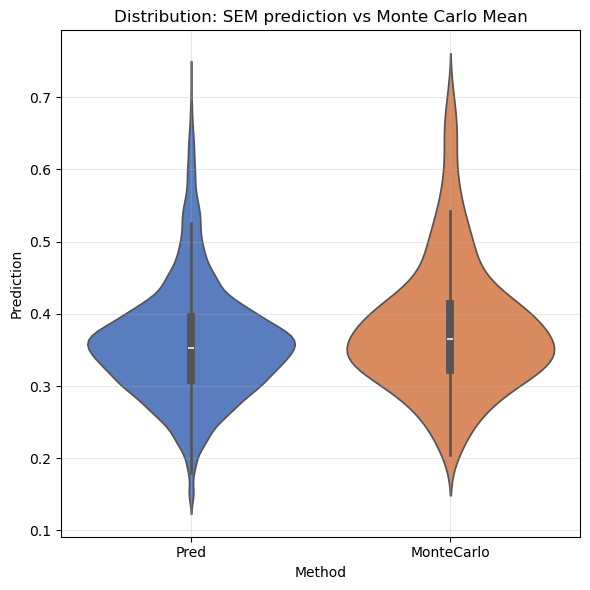

In [61]:
import seaborn as sns
df_compare = pd.DataFrame({
    'Pred': gdf['y_pred_ols'],
    'MonteCarlo': gdf_ols['y_pred_mc_mean']
}).melt(var_name='Method', value_name='Prediction')

# Violin plot
plt.figure(figsize=(6, 6))
sns.violinplot(x='Method', y='Prediction', data=df_compare, inner='box', palette='muted')

plt.title("Distribution: SEM prediction vs Monte Carlo Mean")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [63]:
print(gdf["y_pred_ols"].describe())
print(gdf_ols["y_pred_mc_mean"].describe())

count    12076.000000
mean         0.359086
std          0.079147
min          0.147290
25%          0.308695
50%          0.353363
75%          0.395793
max          0.726182
Name: y_pred_ols, dtype: float64
count    378.000000
mean       0.380194
std        0.090956
min        0.204155
25%        0.322762
50%        0.364491
75%        0.414244
max        0.705392
Name: y_pred_mc_mean, dtype: float64


#### Summary Statistics

Descriptive stats for the two predictions are slightly different:

| Statistic   | Prediction         | Monte Carlo Mean |
|----------|--------------|------------------|
| Mean     |  0.359086       | 0.380194          |
| Std Dev  | 0.079147       | 0.090956           |
| Median   | 0.353363       | 0.364491           |
| Min-Max  | 0.147290–0.726182   | 0.204155–0.705392     |

These results show that:
- The Monte Carlo mean prediction (0.380) is slightly higher than the point estimate (0.359), indicating a small upward bias introduced by uncertainty propagation.
- The Monte Carlo predictions have higher variability (0.091 vs. 0.079).
- The Monte Carlo median is also higher, reinforcing the idea that simulations tend to increase the central tendency slightly.













